In [3]:
import cv2

In [4]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [5]:
def detect_faces(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)
    return img


In [6]:
cap = cv2.VideoCapture(0)  # Запуск веб-камеры. 0 - это индекс камеры. Если у вас их несколько, можете попробовать 1, 2 и т. д.

while True:
    ret, frame = cap.read()  # Чтение кадра
    if not ret:
        break
    frame = detect_faces(frame)  # Распознавание лиц
    cv2.imshow('Face Detection', frame)  # Отображение кадра

    if cv2.waitKey(1) & 0xFF == ord('q'):  # Закрыть окно при нажатии 'q'
        break

cap.release()
cv2.destroyAllWindows()

QObject::moveToThread: Current thread (0x33f4ac10) is not the object's thread (0x340d0a10).
Cannot move to target thread (0x33f4ac10)

QObject::moveToThread: Current thread (0x33f4ac10) is not the object's thread (0x340d0a10).
Cannot move to target thread (0x33f4ac10)

QObject::moveToThread: Current thread (0x33f4ac10) is not the object's thread (0x340d0a10).
Cannot move to target thread (0x33f4ac10)

QObject::moveToThread: Current thread (0x33f4ac10) is not the object's thread (0x340d0a10).
Cannot move to target thread (0x33f4ac10)

QObject::moveToThread: Current thread (0x33f4ac10) is not the object's thread (0x340d0a10).
Cannot move to target thread (0x33f4ac10)

QObject::moveToThread: Current thread (0x33f4ac10) is not the object's thread (0x340d0a10).
Cannot move to target thread (0x33f4ac10)

QObject::moveToThread: Current thread (0x33f4ac10) is not the object's thread (0x340d0a10).
Cannot move to target thread (0x33f4ac10)

QObject::moveToThread: Current thread (0x33f4ac10) is n

In [2]:
!pip install face-recognition

In [1]:
from PIL import Image
image = "/home/pavel/downloads_file/leonardo-dicaprio_70.jpg"
image2 = "/home/pavel/downloads_file/images2.jpg"

In [3]:
from keras.applications.vgg16 import preprocess_input
from keras.models import Model
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
# Загрузка модели VGG-Face
from keras.applications.vgg16 import VGG16

from keras.preprocessing import image
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
import matplotlib.pyplot as plt


I0000 00:00:1773754664.548259   17443 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
base_model = VGG16(weights='imagenet')
model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)
# Загрузка изображения лица
img_path = image
img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Получение вектора признаков для лица
features = model.predict(x)

# Теперь вы можете использовать вектор признаков для сравнения с другими векторами
# или для классификации лиц, или для любых других задач, связанных с распознаванием лиц.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step


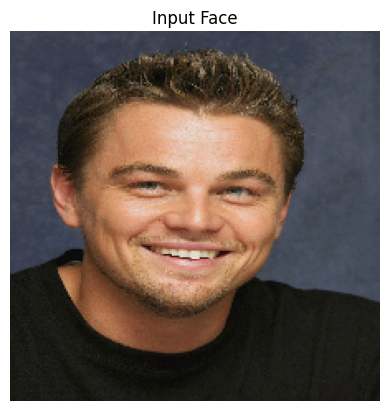

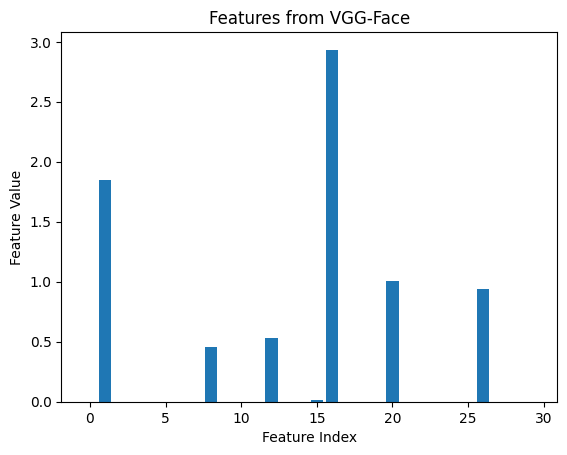

In [10]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Загрузка модели VGG-Face
base_model = VGG16(weights='imagenet')
model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)

# Загрузка и предварительная обработка изображения лица
img_path = image
img = load_img(img_path, target_size=(224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Получение вектора признаков для лица
features = model.predict(x)

# Отображение изображения
plt.imshow(img)
plt.axis('off')
plt.title('Input Face')
plt.show()

# Отображение первых 30 признаков для наглядности (вы можете отобразить больше или меньше признаков)
plt.bar(range(30), features[0][:30])
plt.title('Features from VGG-Face')
plt.xlabel('Feature Index')
plt.ylabel('Feature Value')
plt.show()

In [16]:
import cv2

# Загрузите предварительно обученный каскадный классификатор лиц
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Чтение изображения
img = cv2.imread("/home/pavel/downloads_file/images2.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Детекция лица
faces = face_cascade.detectMultiScale(gray, 1.1, 4)
for (x, y, w, h) in faces:
    face_roi = img[y:y+h, x:x+w]  # извлекаем ROI лица для дальнейшего анализа

In [ ]:
face_roi

In [19]:
face_img = cv2.resize(face_roi, (224, 224))
x = img_to_array(face_img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Извлечение дескрипторов лица
toretto_features = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step


In [20]:
np.save('Dkaprio2_features.npy', toretto_features)

In [21]:
saved_features = np.load('Dkaprio2_features.npy')

In [25]:
import cv2
import numpy as np
from keras.applications.vgg16 import VGG16, preprocess_input
from keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array


# 1. Инициализация модели VGG-Face и извлечение слоя fc2
base_model = VGG16(weights='imagenet')
model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc2').output)

# 2. Функция для детекции и извлечения признаков лица
def get_face_features(img_path):
    # Детекция лица с использованием OpenCV
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    for (x, y, w, h) in faces:
        face_roi = img[y:y+h, x:x+w]

    face_img = cv2.resize(face_roi, (224, 224))
    x = img_to_array(face_img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    features = model.predict(x)
    return features

# 3. Сравнение признаков лица
def is_match(saved_features, new_features, threshold=10):
    distance = np.linalg.norm(saved_features - new_features)
    return distance < threshold

# 4. Демонстрация функциональности
saved_features = np.load('Dkaprio2_features.npy')
new_image_path = image # Замените на путь к новому изображению
new_features = get_face_features(new_image_path)

if is_match(saved_features, new_features):
    print("This is Dkaprio!")
else:
    print("This is not Dkaprio.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
This is not Dkaprio.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step


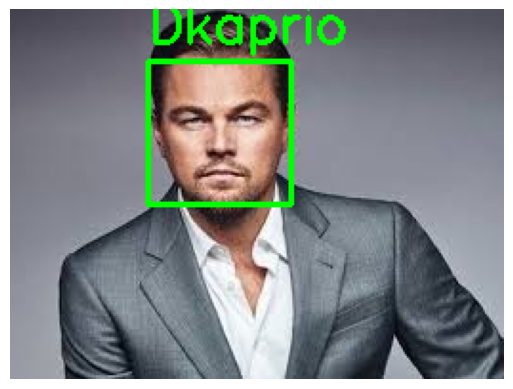

In [27]:
def display_image_with_results(img_path, features):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    for (x, y, w, h) in faces:
        if is_match(saved_features, features):
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(img, "Dkaprio", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        else:
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)
            cv2.putText(img, "Not Dkaprio", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

    # Если вы работаете в Jupyter Notebook:
    from matplotlib import pyplot as plt
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Конвертация из BGR в RGB для корректного отображения в matplotlib
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Теперь вызываем функцию:
new_image_path = image2
new_features = get_face_features(new_image_path)
display_image_with_results(new_image_path, new_features)